<a href="https://colab.research.google.com/github/Clara3786/Project-Genome-Scale-CRISPR-Cas9-Knockout-Screening-in-Human-Cells/blob/main/Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Project card**

*Tove Brunell & Clara Carlborg*


**The paper:**
Genome-Scale CRISPR-Cas9 Knockout Screening in Human Cells
Link: https://www.science.org/doi/10.1126/science.1247005

**The data object:**
The data is the proportion of frameshift and in-frame mutations after sgRNA:s targets the EGFP gene in HEK293T cells. After sgRNA has attached to the target, the lentiCRISPR mechanism can result in a deletion, insertion, or substitution in the EGFP gene, leading to a frameshift or in-frame mutation. The data were derived from Figure S2, B.

**The random variable chosen:**
Frame-shift mutation efficiency fraction

**What the paper does:**
This paper consists of CRISPR-Cas9 experiments conducted on human melanoma cells to investigate potential genes that result in the nonfunctioning of the cancer medication vemurafenib.

The authors created a library of 64,751 different lentiviral vectors with unique sgRNAs that targeted a total of 18,080 genes in human cells. To determine whether the knockout of the gene targeted by a specific sgRNA affected vemurafenib function, the transduced cells were treated with vemurafenib, and the sgRNAs of the surviving cells were further investigated. This to get an idea of what genes are essential for the functioning of vemurafenib.

Before the final experiment was performed on the cancer cells, the lentiCRISPR mechanism had to be tested. To do this, they created six vectors, each consisting of a specific sgRNA for the enhanced green fluorescent protein (EGFP) gene. Each vector was transduced into a human embryonic kidney (HEK) 293T cell that contained one copy of the EGFP gene. If the sgRNA targets the EGFP gene, Cas9 will bind to the gene and make a dsDNA cut. The repair mechanism in the cell will try to repair the dsDNA break, and this can either result in a total repair or in an in-frame or frameshift mutation. If a frameshift mutation occurs, this often means that the gene is not functioning. After the experiment, the EGFP gene was deep sequenced, and it was shown that 92 ± 9% of the reads contained an insertion or deletion. The graph we will further investigate in this project is whether that insertion/deletion led to an in-frame or frameshift mutation. The fractions of these are shown in Figure S2,B in the paper.

**The generative model proposed:**
Binomial distribution.

**Parameters and assumptions:**


**The forward simulation:**


**The parameterization/fitting:**


**What/if the model adds to the paper:**


**Model limitations/how it breaks:**


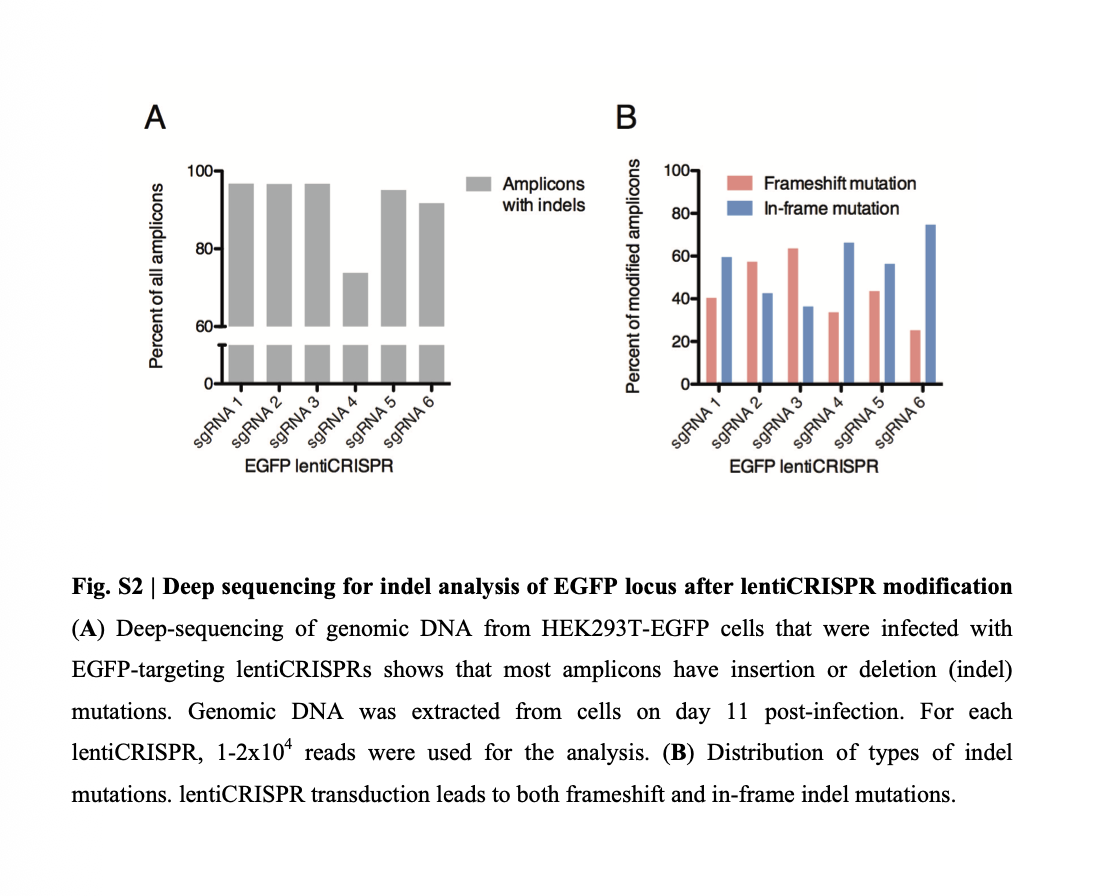

In [ ]:
import math
import matplotlib.pyplot as plt

In [ ]:
frameshift = [40, 58, 62, 35, 43, 23]
inframe = [60, 42, 38, 65, 57, 77]

def mean(values):
    """The sample mean, the sum over the list divided by its length."""
    total = 0.0
    for v in values:
        total = total + v
    return total / len(values)

def std(values):
    """The sample standard deviation, the root of the average squared deviation from the mean."""
    m = mean(values)
    total = 0.0
    for v in values:
        total = total + (v - m) ** 2
    return (total / len(values)) ** 0.5

print("Frameshift mean", round(mean(frameshift), 2), "Standard deviation", round(std(frameshift), 2))


Frameshift mean 43.5 Standard deviation 13.28


In [ ]:
p_data = 0.44

A_LCG = 1664525
C_LCG = 1013904223
M_LCG = 2 ** 32


def lcg(state, a, c, m):
    """The next state of a linear congruential generator: s_{i+1} = (a * s_i + c) mod m."""
    return (a * state + c) % m


def uniforms(k, seed):
    """A list of k numbers on [0, 1): the generator run k times from the seed, each state divided by m."""
    out = [0.0] * k
    state = seed
    for i in range(k):
        state = lcg(state, A_LCG, C_LCG, M_LCG)
        out[i] = state / M_LCG
    return out


def position_of_min(values):
    """The position of the smallest value in the list."""
    best = 0
    for i in range(len(values)):
        if values[i] < values[best]:
            best = i
    return best

In [ ]:
def simulate(frameshift, p, n_reads=100, seed=8):
    rs = uniforms(frameshift * n_reads, seed)
    percent_frameshift = [0] * frameshift
    percent_inframe = [0] * frameshift


    for i in range(frameshift):
      count = 0
      for c in range(n_reads):
        if rs[i * n_reads + c] < p:
          count += 1
      percent_frameshift[i] = count/n_reads
      percent_inframe[i] = 1 - percent_frameshift[i]


    return percent_frameshift, percent_inframe


percent_frameshift, percent_inframe = simulate(6, p_data)

print(percent_inframe)
print(percent_frameshift)

[0.49, 0.6, 0.6, 0.48, 0.75, 0.51]
[0.51, 0.4, 0.4, 0.52, 0.25, 0.49]


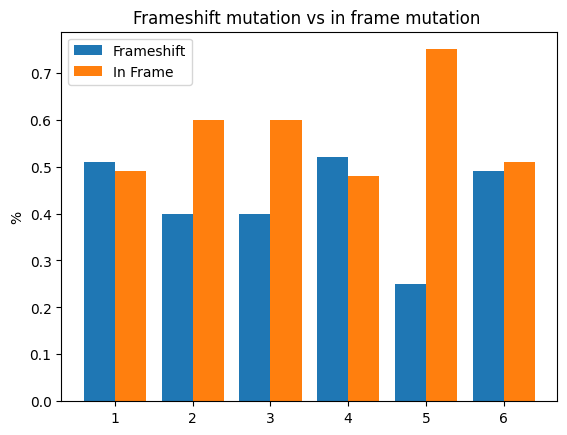

In [ ]:
import numpy as np

sgrna = ["1", "2", "3", "4", "5", "6"]
# Bar width and x locations
w, x = 0.4, np.arange(len(sgrna))

fig, ax = plt.subplots()
ax.bar(x - w/2, percent_frameshift, width=w, label='Frameshift')
ax.bar(x + w/2, percent_inframe, width=w, label='In Frame')

ax.set_xticks(x)
ax.set_xticklabels(sgrna)
ax.set_ylabel('%')
ax.set_title('Frameshift mutation vs in frame mutation ')
ax.legend()

plt.show()

In [ ]:
def factorial(x):
    """x! as a product, 0! = 1."""

    total = 1
    for k in range(1, x + 1):
        total = total * k
    return total

def binomial(n, p, k):
  """ Binomial distribution """

  formula = factorial(n) * p ** k * (1 - p) ** (n - k)/ (factorial(k)* factorial(n-k))
  return formula

In [ ]:
print(binomial(100, 0.5, 40))

0.010843866711637989


In [ ]:

def nll(p):
    """ Minus the log of the likelihood """
    total = 0

    for frame in frameshift:
      x = i/100
      total -= math.log(binomial(100, p, frame))

    return total

grid = [0.2 + 0.001 * i for i in range(601)]
scores = [0.0] * len(grid)

for i in range(len(grid)):
  scores[i] = nll(grid[i])

p_hat = grid[position_of_min(scores)]

print(p_hat)

0.43500000000000005


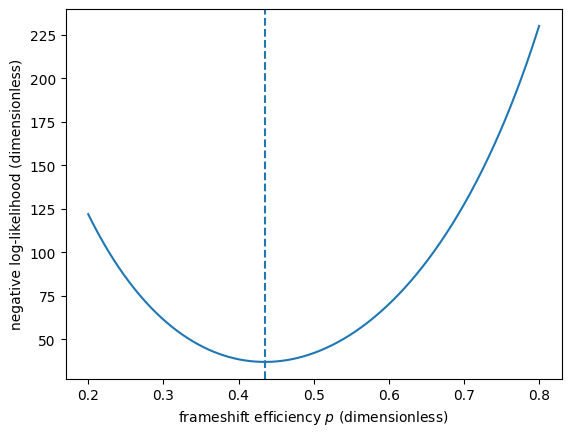

In [ ]:
plt.plot(grid, scores)
plt.axvline(p_hat, ls="--")
plt.xlabel("frameshift efficiency $p$ (dimensionless)")
plt.ylabel("negative log-likelihood (dimensionless)")
plt.show()

In [ ]:
h = 0.01

curvature = (nll(p_hat+h) - 2*nll(p_hat) + nll(p_hat-h)) / h**2
se_p = 1/(curvature**0.5)

In [ ]:
print("ok  p_hat", round(p_hat, 3), "+/-", round(se_p, 4), "  curvature", round(curvature, 1))

ok  p_hat 0.435 +/- 0.0202   curvature 2441.8


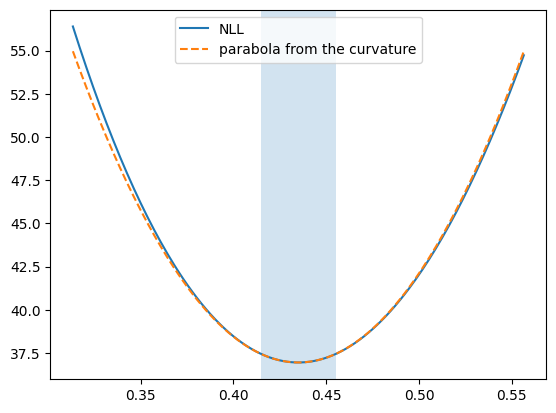

In [ ]:
near = [p_hat - 6 * se_p + 12 * se_p * i / 200 for i in range(201)]

plt.plot(near, [nll(p) for p in near], label="NLL")
plt.plot(near, [nll(p_hat) + 0.5 * curvature * (p - p_hat) ** 2 for p in near], "--",
         label="parabola from the curvature")
plt.axvspan(p_hat - se_p, p_hat + se_p, alpha=0.2)
plt.legend()
plt.show()


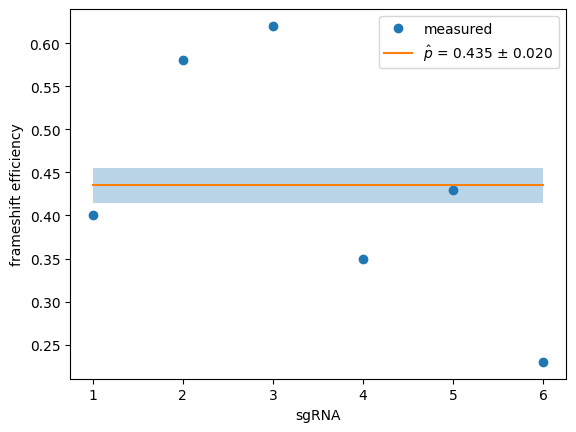

In [ ]:
frameshift2 = [0.40, 0.58, 0.62, 0.35, 0.43, 0.23]

p_hat_lst = [p_hat] * 6

low = p_hat - se_p
high = p_hat + se_p

plt.plot(sgrna, frameshift2, "o", label="measured")
plt.plot(sgrna, p_hat_lst, "-",
         label=f"$\\hat p$ = {p_hat:.3f} $\\pm$ {se_p:.3f}")
plt.fill_between(sgrna, low, high, alpha=0.3)
plt.xlabel("sgRNA")
plt.ylabel("frameshift efficiency")
plt.legend()
plt.show()